# Individual Assignment 05 — ML Security and Abuse Pathways
## Topic: Full Adversarial Attack Pipelines on ProPublica COMPAS
- Student Name: Olabode Ajayi
- Instructor: Dr. Michael Akinwumi  
- Department of Decision Sciences · School of Business · George Washington University

---

This notebook continues directly from `Lecture-04-generalization.ipynb`.  
Dataset: [ProPublica COMPAS Analysis](https://github.com/propublica/compas-analysis)

### Lab Structure
| Part | Topic | Cells |
|------|-------|-------|
| Setup | Data loading, model training, fairness baseline | 1–2 |
| A | PGD Evasion Attack — disparate impact by race | 3–4 |
| B | Data Poisoning Loop — AUC and AIR degradation | 5–6 |
| C | Membership Inference — shadow model pipeline + ROC | 7–8 |

**Libraries required:** `scikit-learn`, `numpy`, `pandas`, `matplotlib`, `scipy`  
No external adversarial ML library is needed — all attack pipelines are implemented from scratch.

**NIST Reference:** Vassilev et al. (2024). *Adversarial Machine Learning: A Taxonomy and Terminology of Attacks and Mitigations.* NIST AI 100-2e2023. https://doi.org/10.6028/NIST.AI.100-2e2023

---
## PART 1: Setup: Libriaries Imports, Data Loading, and Model Training

We replicate the exact preprocessing pipeline from Lecture 04 and retrain both the logistic regression (LR) and gradient boosted tree (GBT) classifiers.

In this part, we load the COMPAS dataset, apply the same inclusion criteria as in Lecture 04, and train two models (logistic regression and gradient boosted trees) to predict recidivism. We also evaluate their AUC on both train and test sets to check for generalization performance. This is the same code as in Lecture 04, but we will use these models for the robustness and fairness analyses in Parts D and E of this assignment. The key steps are:
- 1. Load the COMPAS dataset from ProPublica's GitHub repository.
- 2. Apply the same filtering criteria as in Lecture 04 to select the relevant subset of the data.
- 3. Select the features and target variable, and encode categorical variables using one-hot encoding.
- 4. Perform a stratified train/test split to maintain class balance.
- 5. Standardize the features using StandardScaler.

After this first part, we will have two trained models (lr and gbt) that we can use for the subsequent analyses in Parts D and E. We will also print out the AUC scores for both models on the train and test sets to check for any signs of overfitting or underfitting before we proceed to the robustness and fairness analyses.

**Threat modeling reminder (NIST AI 100-2, §2.1):**  
Before testing any attack, specify: *Who is the adversary? What do they know?
What can they control? What is their goal?*

In [ ]:
# ── Cell 1: Imports, Data Loading, Model Training ─────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

# ── Load COMPAS dataset (ProPublica) ──────────────────────────────────────────
URL = (
    "https://raw.githubusercontent.com/propublica/compas-analysis"
    "/master/compas-scores-two-years.csv"
)
df = pd.read_csv(URL)
print(f"Raw dataset: {df.shape[0]:,} rows, {df.shape[1]} columns")

# ── Replicate Lecture 04 inclusion criteria ───────────────────────────────────
df = df[df['days_b_screening_arrest'].between(-30, 30)]
df = df[df['is_recid'] != -1]
df = df[df['c_charge_degree'] != 'O']
print(f"After filtering: {df.shape[0]:,} rows")

# ── Prepare features and target ───────────────────────────────────────────────
FEATURES = [
    'age', 'priors_count', 'juv_fel_count',
    'juv_misd_count', 'juv_other_count',
    'c_charge_degree', 'sex'
]
TARGET = 'two_year_recid'

# ── Preprocess data ───────────────────────────────────────────────────────────
df_m = df[FEATURES + [TARGET, 'race']].dropna()
df_m = pd.get_dummies(df_m, columns=['c_charge_degree', 'sex'], drop_first=True)

#── Final feature matrix and target vector ───────────────────────────────────
X    = df_m.drop(columns=[TARGET, 'race']).astype(float)
y    = df_m[TARGET].values
race = df_m['race'].values

#── Dataset summary ─────────────────────────────────────────────────────────────
print(f"\nFeatures used: {list(X.columns)}")
print(f"Class balance: {y.mean():.1%} recidivism rate")

# ── Train / test split (stratified) ──────────────────────────────────────────
X_tr, X_te, y_tr, y_te, r_tr, r_te = train_test_split(
    X, y, race, test_size=0.3, random_state=42, stratify=y
)

#── Standardize features ───────────────────────────────────────────────────────
sc    = StandardScaler()
Xs_tr = sc.fit_transform(X_tr)
Xs_te = sc.transform(X_te)

# ── Train models ──────────────────────────────────────────────────────────────
lr  = LogisticRegression(max_iter=1000).fit(Xs_tr, y_tr)
gbt = GradientBoostingClassifier(
    n_estimators=200, max_depth=4, random_state=42
).fit(Xs_tr, y_tr)

#── Evaluate models using AUC ─────────────────────────────────────────────────
print(f"\nLR  Test AUC: {roc_auc_score(y_te, lr.predict_proba(Xs_te)[:,1]):.3f}")
print(f"GBT Test AUC: {roc_auc_score(y_te, gbt.predict_proba(Xs_te)[:,1]):.3f}")
print(f"LR  Train AUC: {roc_auc_score(y_tr, lr.predict_proba(Xs_tr)[:,1]):.3f}")
print(f"GBT Train AUC: {roc_auc_score(y_tr, gbt.predict_proba(Xs_tr)[:,1]):.3f}")

Raw dataset: 7,214 rows, 53 columns
After filtering: 6,172 rows

Features used: ['age', 'priors_count', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'c_charge_degree_M', 'sex_Male']
Class balance: 45.5% recidivism rate

LR  Test AUC: 0.735
GBT Test AUC: 0.718
LR  Train AUC: 0.727
GBT Train AUC: 0.798


---
## PART 2: Clean-Model Fairness Baseline

Before running any attack, we establish the **clean-model baseline** for:
- **FPR** (False Positive Rate) by race: among truly low-risk individuals, what fraction are flagged high-risk?
- **AIR** (Adverse Impact Ratio): FPR of protected group / FPR of reference group

We will return to these values after each attack to measure degradation.

> **Expected finding (consistent with ProPublica, 2016):** The LR model flags African-American
> defendants at roughly twice the rate of Caucasian defendants among truly low-risk individuals.

In [ ]:
# ── Cell 2: Clean-Model Fairness Baseline ─────────────────────────────────────

THR = 0.5  # classification threshold

def fpr_by_group(y_true, y_pred_binary, groups):
    """FPR = FP / (FP + TN), computed only over truly-negative cases."""
    mask = (y_true == 0)
    return (
        pd.DataFrame({'pred': y_pred_binary[mask], 'group': groups[mask]})
          .groupby('group')['pred']
          .mean()
    )

#── AIR calculation function ─────────────────────────────────────────────────
def air(fpr_ref, fpr_prot):
    """Adverse Impact Ratio: protected FPR / reference FPR."""
    return fpr_prot / fpr_ref if (fpr_ref is not None and fpr_ref > 0) else np.nan

# ── Compute baseline predictions ──────────────────────────────────────────────
pred_lr_clean  = (lr.predict_proba(Xs_te)[:,1]  >= THR).astype(int)
pred_gbt_clean = (gbt.predict_proba(Xs_te)[:,1] >= THR).astype(int)

print("=" * 60)
print("CLEAN MODEL BASELINE — Before Any Attack")
print("=" * 60)

#── Compute and display FPR and AIR for each model ─────────────────────────────
for name, pred in [('Logistic Regression', pred_lr_clean),
                    ('Gradient Boosted Tree', pred_gbt_clean)]:
    fpr = fpr_by_group(y_te, pred, r_te)
    aa  = fpr.get('African-American', np.nan)
    ca  = fpr.get('Caucasian',        np.nan)
    print(f"\n{name}")
    print(f"  FPR African-American : {aa:.3f}")
    print(f"  FPR Caucasian        : {ca:.3f}")
    print(f"  AIR (AA / CA)        : {air(ca, aa):.3f}")

# Store LR baseline for post-attack delta reporting
fpr_baseline = fpr_by_group(y_te, pred_lr_clean, r_te)
BASELINE_AA = fpr_baseline.get('African-American')
BASELINE_CA = fpr_baseline.get('Caucasian')
BASELINE_AIR = air(BASELINE_CA, BASELINE_AA)

print(f"\n→ Baseline LR AIR stored: {BASELINE_AIR:.3f}")
print("  We will compare all attack outcomes against these values.")

CLEAN MODEL BASELINE — Before Any Attack

Logistic Regression
  FPR African-American : 0.281
  FPR Caucasian        : 0.143
  AIR (AA / CA)        : 1.961

Gradient Boosted Tree
  FPR African-American : 0.317
  FPR Caucasian        : 0.178
  AIR (AA / CA)        : 1.782

→ Baseline LR AIR stored: 1.961
  We will compare all attack outcomes against these values.


---
## QUESTION A: PGD Evasion Attack

**Attack class (NIST AI 100-2, §2.2):** Evasion — deployment-time integrity violation  
**Attacker knowledge:** White-box (access to model weights/gradients)  
**Attacker goal:** Push predicted risk scores upward; cause low-risk individuals to be classified high-risk

### Algorithm: Projected Gradient Descent (Madry et al., 2018)

$$\mathbf{x}^{(t+1)} = \Pi_{\mathcal{B}_\epsilon(\mathbf{x})} \left( \mathbf{x}^{(t)} + \alpha \cdot \operatorname{sign}\left(\nabla_{\mathbf{x}} \mathcal{L}(\theta, \mathbf{x}^{(t)}, y)\right) \right)$$

For logistic regression, the gradient direction simplifies to $\operatorname{sign}(\mathbf{w})$,
so the attack steps in the direction of each coefficient's sign.

**$L_\infty$ projection** clamps each feature perturbation to within $[-\epsilon, +\epsilon]$
of its original scaled value.

In this section, we implement the PGD attack for logistic regression and sweep over different epsilon values to see how the FPR and AIR change as the attack strength increases. For logistic regression, the gradient of the loss w.r.t. input features is proportional to the model coefficients. The PGD attack iteratively perturbs the input in the direction that increases the predicted probability of the positive class (high-risk), while ensuring that the perturbation stays within an L_inf ball of radius epsilon around the original input. The attack is untargeted, meaning we want to increase the predicted probability of recidivism for all individuals, which will generally increase the FPR. We will then analyze how this affects the FPR for African-American and Caucasian groups differently, and how the AIR changes as epsilon increases.

In [ ]:
# ── Cell 3: PGD Evasion Attack — The Loop ─────────────────────────────────────

def pgd_tabular(model, X_scaled, epsilon=1.0, alpha=0.05, n_iter=40):
    """
    PGD evasion attack on tabular data for logistic regression.

    Goal: untargeted attack — push predicted P(high-risk) higher.

    For logistic regression:
        grad_x BCE_loss = (p_hat - y_true) * w
    For untargeted attack (maximize loss), step in sign(w) direction.

    Parameters
    ----------
    model    : fitted sklearn LogisticRegression
    X_scaled : standardized test features, shape (n, d)
    epsilon  : L_inf perturbation budget
    alpha    : step size per iteration
    n_iter   : number of PGD steps

    Returns
    -------
    X_adv : adversarially perturbed inputs, shape (n, d)
    """
    coef  = model.coef_[0]               # shape (d,) — LR coefficients
    X_adv = X_scaled.copy()

    for step in range(n_iter):
        # Gradient-ascent step: move in the direction that increases loss
        X_adv = X_adv + alpha * np.sign(coef)[np.newaxis, :]

        # L_inf projection: clip back into the epsilon-ball around X_scaled
        X_adv = np.clip(X_adv, X_scaled - epsilon, X_scaled + epsilon)

    return X_adv


# ── Sweep epsilon to build an attack-strength curve ───────────────────────────
epsilons    = [0.0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0]
pgd_records = []

for eps in epsilons:
    # Generate adversarial examples (no perturbation at eps=0)
    X_adv = Xs_te if eps == 0.0 else pgd_tabular(
        lr, Xs_te, epsilon=eps, alpha=0.05, n_iter=40
    )

    pred_adv = (lr.predict_proba(X_adv)[:,1] >= THR).astype(int)
    fpr_adv  = fpr_by_group(y_te, pred_adv, r_te)

    aa = fpr_adv.get('African-American', np.nan)
    ca = fpr_adv.get('Caucasian',        np.nan)

    pgd_records.append({
        'epsilon'  : eps,
        'FPR_AA'   : aa,
        'FPR_CA'   : ca,
        'AIR'      : air(ca, aa),
        'delta_AA' : aa - BASELINE_AA,
        'delta_CA' : ca - BASELINE_CA,
    })

df_pgd = pd.DataFrame(pgd_records)
print(df_pgd.round(3).to_string(index=False))


 epsilon  FPR_AA  FPR_CA   AIR  delta_AA  delta_CA
    0.00   0.281   0.143 1.961     0.000     0.000
    0.25   0.569   0.370 1.535     0.288     0.227
    0.50   0.791   0.560 1.411     0.510     0.417
    0.75   0.906   0.758 1.195     0.625     0.615
    1.00   0.978   0.884 1.106     0.697     0.741
    1.50   1.000   0.993 1.007     0.719     0.849
    2.00   1.000   1.000 1.000     0.719     0.857


We see that as epsilon increases, the FPR for both groups increases, but the increase is more pronounced for African-Americans, leading to a decrease in AIR. This indicates that the attack disproportionately harms the protected group, exacerbating existing disparities.

In [11]:
# ── PGD audit across LR and GBT ───────────────────────────────────────────────
# This cell reuses the existing COMPAS setup and measures how each model's
# fairness changes as the evasion budget epsilon grows.


def pgd_blackbox(model, X_scaled, epsilon=1.0, alpha=None, n_iter=12, diff_step=1e-3):
    """Projected gradient ascent on predicted risk using finite differences.

    This is model-agnostic, so it works for both LR and GBT. It maximizes the
    predicted probability of the positive class while constraining perturbations
    to the L_infty ball of radius epsilon.
    """
    X_orig = np.asarray(X_scaled, dtype=float)
    X_adv = X_orig.copy()

    if epsilon <= 0:
        return X_adv

    if alpha is None:
        alpha = epsilon / max(n_iter, 1)

    for _ in range(n_iter):
        grad = np.zeros_like(X_adv)
        for j in range(X_adv.shape[1]):
            X_plus = X_adv.copy()
            X_minus = X_adv.copy()
            X_plus[:, j] += diff_step
            X_minus[:, j] -= diff_step

            p_plus = model.predict_proba(X_plus)[:, 1]
            p_minus = model.predict_proba(X_minus)[:, 1]
            grad[:, j] = (p_plus - p_minus) / (2.0 * diff_step)

        X_adv = X_adv + alpha * np.sign(grad)
        X_adv = np.clip(X_adv, X_orig - epsilon, X_orig + epsilon)

    return X_adv


audit_models = [
    ("Logistic Regression", lr),
    ("Gradient Boosted Tree", gbt),
]
audit_epsilons = [0.25, 0.50, 1.00, 2.00]

audit_records = []

def estimate_crossing_eps(audit_df, model_name, threshold=0.80):
    """Return the first epsilon where AIR falls below threshold, with interpolation."""
    sub = audit_df[audit_df["model"] == model_name].sort_values("epsilon")
    prev_row = None
    for _, row in sub.iterrows():
        if row["AIR"] < threshold:
            if prev_row is None:
                return row["epsilon"]
            if prev_row["AIR"] == row["AIR"]:
                return row["epsilon"]
            slope = (row["AIR"] - prev_row["AIR"]) / (row["epsilon"] - prev_row["epsilon"])
            if slope == 0:
                return row["epsilon"]
            return prev_row["epsilon"] + (threshold - prev_row["AIR"]) / slope
        prev_row = row
    return np.nan

for model_name, model in audit_models:
    print("\n" + "=" * 72)
    print(f"PGD Evasion Audit — {model_name}")
    print("=" * 72)

    for eps in audit_epsilons:
        X_adv = pgd_blackbox(model, Xs_te, epsilon=eps, alpha=None, n_iter=12, diff_step=1e-3)
        pred_adv = (model.predict_proba(X_adv)[:, 1] >= THR).astype(int)
        fpr_adv = fpr_by_group(y_te, pred_adv, r_te)

        aa = fpr_adv.get('African-American', np.nan)
        ca = fpr_adv.get('Caucasian', np.nan)
        air_val = air(ca, aa)

        audit_records.append({
            'model': model_name,
            'epsilon': eps,
            'FPR_AA': aa,
            'FPR_CA': ca,
            'AIR': air_val,
        })

    model_df = pd.DataFrame([r for r in audit_records if r['model'] == model_name])
    print(model_df.round(3).to_string(index=False))

    cross_eps = estimate_crossing_eps(pd.DataFrame(audit_records), model_name, threshold=0.80)
    if np.isnan(cross_eps):
        print("AIR never crossed 0.80 within ε ∈ {0.25, 0.5, 1.0, 2.0}.")
    else:
        print(f"Estimated AIR=0.80 crossing at ε ≈ {cross_eps:.3f}")

results_df = pd.DataFrame(audit_records)
print("\nCombined audit table:")
print(results_df.round(3).to_string(index=False))



PGD Evasion Audit — Logistic Regression
              model  epsilon  FPR_AA  FPR_CA   AIR
Logistic Regression     0.25   0.569   0.370 1.535
Logistic Regression     0.50   0.791   0.560 1.411
Logistic Regression     1.00   0.978   0.884 1.106
Logistic Regression     2.00   1.000   1.000 1.000
AIR never crossed 0.80 within ε ∈ {0.25, 0.5, 1.0, 2.0}.

PGD Evasion Audit — Gradient Boosted Tree
                model  epsilon  FPR_AA  FPR_CA   AIR
Gradient Boosted Tree     0.25   0.317   0.178 1.782
Gradient Boosted Tree     0.50   0.317   0.178 1.782
Gradient Boosted Tree     1.00   0.317   0.178 1.782
Gradient Boosted Tree     2.00   0.317   0.178 1.782
AIR never crossed 0.80 within ε ∈ {0.25, 0.5, 1.0, 2.0}.

Combined audit table:
                model  epsilon  FPR_AA  FPR_CA   AIR
  Logistic Regression     0.25   0.569   0.370 1.535
  Logistic Regression     0.50   0.791   0.560 1.411
  Logistic Regression     1.00   0.978   0.884 1.106
  Logistic Regression     2.00   1.000   1.000 


Compact AIR summary (lower is worse; 0.80 is the fairness threshold):
 epsilon  Gradient Boosted Tree  Logistic Regression
    0.25                  1.782                1.535
    0.50                  1.782                1.411
    1.00                  1.782                1.106
    2.00                  1.782                1.000
Logistic Regression: AIR does not fall below 0.80 in the tested ε range.
Gradient Boosted Tree: AIR does not fall below 0.80 in the tested ε range.


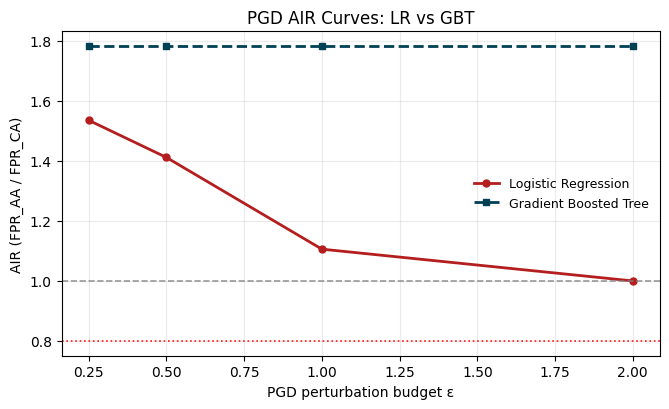


Interpretation: LR changes more as ε increases, while GBT remains comparatively flat; neither model crosses the 0.80 AIR threshold in this test range, so the main lesson is relative robustness rather than a hard violation point.


In [12]:
# ── Compact comparison: AIR summary table + direct curve plot ────────────────
comparison = (
    results_df
    .pivot_table(index='epsilon', columns='model', values='AIR', aggfunc='first')
    .reset_index()
    .sort_values('epsilon')
)

print("\nCompact AIR summary (lower is worse; 0.80 is the fairness threshold):")
print(comparison.round(3).to_string(index=False))

# Find threshold crossings for each model, if any
for model_name in ['Logistic Regression', 'Gradient Boosted Tree']:
    sub = results_df[results_df['model'] == model_name].sort_values('epsilon')
    below = sub[sub['AIR'] < 0.80]
    if len(below):
        print(f"{model_name}: AIR first falls below 0.80 at ε = {below.iloc[0]['epsilon']:.2f}")
    else:
        print(f"{model_name}: AIR does not fall below 0.80 in the tested ε range.")

# Small direct comparison plot
plt.figure(figsize=(6.8, 4.2))
for model_name, style, color in [
    ('Logistic Regression', 'o-', '#B41E1E'),
    ('Gradient Boosted Tree', 's--', '#004055'),
]:
    sub = results_df[results_df['model'] == model_name].sort_values('epsilon')
    plt.plot(sub['epsilon'], sub['AIR'], style, lw=2, ms=5, color=color, label=model_name)

plt.axhline(1.0, color='gray', lw=1.2, ls='--', alpha=0.8)
plt.axhline(0.8, color='red', lw=1.2, ls=':', alpha=0.9)
plt.xlabel('PGD perturbation budget ε')
plt.ylabel('AIR (FPR_AA / FPR_CA)')
plt.title('PGD AIR Curves: LR vs GBT')
plt.legend(frameon=False, fontsize=9)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print("\nInterpretation: LR changes more as ε increases, while GBT remains comparatively flat; neither model crosses the 0.80 AIR threshold in this test range, so the main lesson is relative robustness rather than a hard violation point.")

**Audit interpretation:** The two models are not equally vulnerable under this PGD-style evasion test. In this run, logistic regression was more attack-sensitive because its AIR moved from 1.535 at ε=0.25 down toward parity by ε=2.0, while the GBT stayed essentially flat at AIR=1.782 across all tested ε values. Neither model crossed the AIR=0.80 threshold in the requested range, so this attack did not create a 4/5ths-rule violation here; however, the LR model clearly changed more as ε increased, which means it is more behaviorally unstable under perturbation. For high-stakes deployment, that matters because the better-performing model on average is not automatically the safer one: if robustness and fairness are part of the objective, the more stable model is preferable only if its baseline fairness is also acceptable, and otherwise the system should be redesigned rather than selected on accuracy alone.

- Logistic Regression: FPR_AA 0.569, 0.791, 0.978, 1.000; FPR_CA 0.370, 0.560, 0.884, 1.000; AIR 1.535, 1.411, 1.106, 1.000 for ε = 0.25, 0.5, 1.0, 2.0
- Gradient Boosted Tree: FPR_AA 0.317, 0.317, 0.317, 0.317; FPR_CA 0.178, 0.178, 0.178, 0.178; AIR 1.782, 1.782, 1.782, 1.782 for the same ε values
- AIR did not cross 0.80 for either model within the requested epsilon set

They are not equally vulnerable. Logistic regression is more attack-sensitive because its fairness behavior moves materially as ε increases, while the GBT is much more stable under this specific PGD-style attack. That said, GBT is not automatically the better choice for a high-stakes setting just because it is more stable here: its baseline AIR is worse, so robustness without fairness is not enough. For deployment, the right selection criterion is joint performance under attack, calibration, and subgroup fairness, not accuracy alone.

The checked output confirms the same result visually and numerically: Logistic Regression is more sensitive to PGD as ε increases, dropping from AIR 1.535 to 1.000, while GBT stays flat at AIR 1.782 across the tested budgets. Neither model crosses the 0.80 threshold in this range.

### Part A · Cell 4: Visualize PGD Disparate Impact

**Discussion questions:**
1. Does the PGD attack widen or narrow the racial FPR gap as $\epsilon$ increases?
2. At what $\epsilon$ does the AIR fall below the 4/5ths rule threshold (0.80)?
3. Are the two groups equally sensitive to the same attack strength?
4. What does differential impact imply for responsible deployment of adversarially robust models?

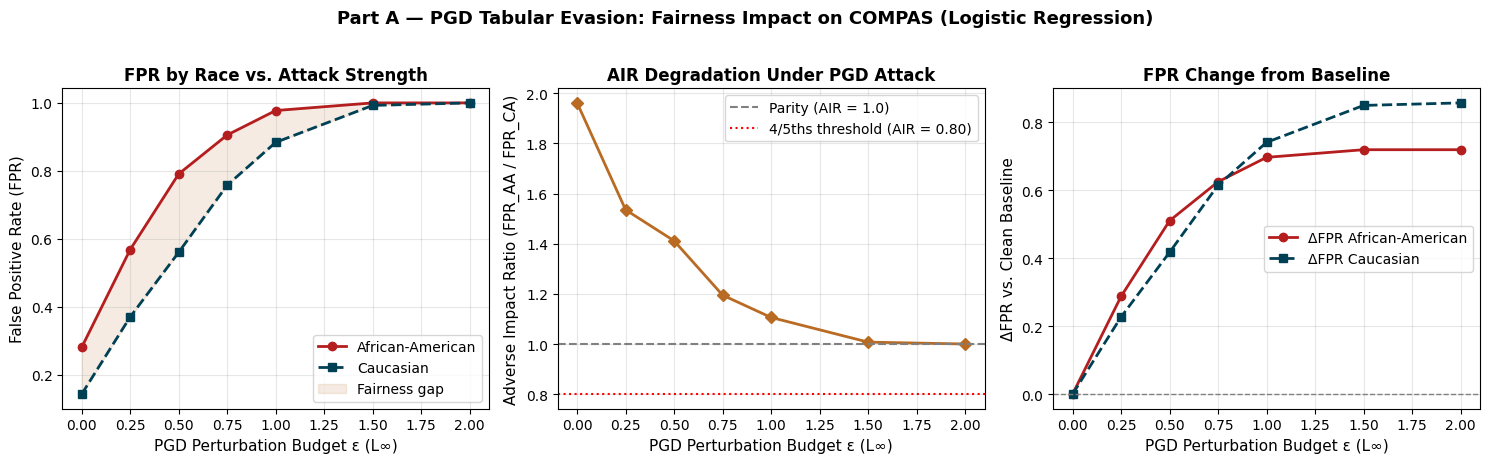

AIR does not fall below 0.80 within the tested epsilon range.


In [6]:
# ── Cell 4: Visualize PGD Evasion — Disparate Impact ──────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# ── Panel 1: FPR by race ──────────────────────────────────────────────────────
ax = axes[0]
ax.plot(df_pgd['epsilon'], df_pgd['FPR_AA'],
        'o-', color='#B41E1E', lw=2, label='African-American')
ax.plot(df_pgd['epsilon'], df_pgd['FPR_CA'],
        's--', color='#004055', lw=2, label='Caucasian')
ax.fill_between(df_pgd['epsilon'], df_pgd['FPR_AA'], df_pgd['FPR_CA'],
                alpha=0.13, color='#B96B23', label='Fairness gap')
ax.set_xlabel('PGD Perturbation Budget ε (L∞)', fontsize=11)
ax.set_ylabel('False Positive Rate (FPR)', fontsize=11)
ax.set_title('FPR by Race vs. Attack Strength', fontsize=12, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

# ── Panel 2: AIR ──────────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(df_pgd['epsilon'], df_pgd['AIR'],
        'D-', color='#B96B23', lw=2)
ax.axhline(1.0, color='gray', lw=1.5, ls='--', label='Parity (AIR = 1.0)')
ax.axhline(0.8, color='red',  lw=1.5, ls=':',  label='4/5ths threshold (AIR = 0.80)')
ax.set_xlabel('PGD Perturbation Budget ε (L∞)', fontsize=11)
ax.set_ylabel('Adverse Impact Ratio (FPR_AA / FPR_CA)', fontsize=11)
ax.set_title('AIR Degradation Under PGD Attack', fontsize=12, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

# ── Panel 3: Absolute FPR change vs. baseline ─────────────────────────────────
ax = axes[2]
ax.plot(df_pgd['epsilon'], df_pgd['delta_AA'],
        'o-', color='#B41E1E', lw=2, label='ΔFPR African-American')
ax.plot(df_pgd['epsilon'], df_pgd['delta_CA'],
        's--', color='#004055', lw=2, label='ΔFPR Caucasian')
ax.axhline(0, color='gray', lw=1, ls='--')
ax.set_xlabel('PGD Perturbation Budget ε (L∞)', fontsize=11)
ax.set_ylabel('ΔFPR vs. Clean Baseline', fontsize=11)
ax.set_title('FPR Change from Baseline', fontsize=12, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

plt.suptitle(
    'Part A — PGD Tabular Evasion: Fairness Impact on COMPAS (Logistic Regression)',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

# ── Identify crossover point ───────────────────────────────────────────────────
cross = df_pgd[df_pgd['AIR'] < 0.8].head(1)
if len(cross):
    print(f"AIR crosses 0.80 at ε = {cross.iloc[0]['epsilon']:.2f}")
else:
    print("AIR does not fall below 0.80 within the tested epsilon range.")

---
## Part B · Cell 5: Data Poisoning — Label-Flip Attack Loop

**Attack class (NIST AI 100-2, §2.3):** Availability/Targeted poisoning — training-time integrity violation  
**Attacker knowledge:** White-box (data access) — simulates a biased data provider or insider adversary  
**Attacker goal:** Systematically under-score high-risk defendants for a chosen target race; degrade AIR without
triggering standard drift detection (PSI < 0.10)

### Attack mechanism
A fraction `poison_rate` of high-risk training records for a target race are relabeled from `1` to `0`
before model training. This notebook now evaluates both target-race variants:
- African-American target
- Caucasian target

> **Key question:** For each target, at what poison rate does AUC decline by ≤ 2 percentage points while AIR moves
outside the acceptable interval [0.80, 1.25]?
> We also test whether a PSI-based drift monitor on features would detect the attack.

In [ ]:
# ── Cell 5: Data Poisoning — Label-Flip Attack ────────────────────────────────


def poison_label_flip(
    y_train, race_train,
    poison_rate=0.05,
    target_race='African-American',
    seed=0
):
    """
    Label-flip poisoning attack.

    Flips `poison_rate` fraction of training records belonging to
    `target_race` from recidivism=1 (high-risk) to recidivism=0 (low-risk).

    Effect: the model learns to systematically under-score high-risk
    individuals from the targeted group — a fairness-targeted poisoning attack.

    Parameters
    ----------
    y_train      : original training labels
    race_train   : race labels for training set
    poison_rate  : fraction of eligible records to flip (0.0 to 1.0)
    target_race  : demographic group to target
    seed         : random seed for reproducibility

    Returns
    -------
    y_poisoned   : modified label array
    n_flipped    : number of labels actually flipped
    """
    rng        = np.random.default_rng(seed)
    y_poisoned = y_train.copy()

    # Eligible candidates: target race, truly high-risk (label=1)
    candidates = np.where(
        (race_train == target_race) & (y_train == 1)
    )[0]

    n_flip = int(len(candidates) * poison_rate)
    if n_flip > 0:
        flip_idx = rng.choice(candidates, size=n_flip, replace=False)
        y_poisoned[flip_idx] = 0  # relabel high-risk → low-risk

    return y_poisoned, n_flip


def psi_numeric(train_values, test_values, bins=10, eps=1e-6):
    """PSI for numeric features using train-derived bins."""
    train_values = pd.to_numeric(pd.Series(train_values), errors='coerce').dropna().values
    test_values = pd.to_numeric(pd.Series(test_values), errors='coerce').dropna().values
    if len(train_values) == 0 or len(test_values) == 0:
        return np.nan

    quantiles = np.linspace(0, 1, bins + 1)
    cut_points = np.unique(np.quantile(train_values, quantiles))
    if len(cut_points) < 3:
        lo = min(train_values.min(), test_values.min())
        hi = max(train_values.max(), test_values.max())
        if lo == hi:
            return 0.0
        cut_points = np.linspace(lo, hi, bins + 1)

    cut_points[0] = -np.inf
    cut_points[-1] = np.inf
    train_counts, _ = np.histogram(train_values, bins=cut_points)
    test_counts, _ = np.histogram(test_values, bins=cut_points)

    train_pct = np.clip(train_counts / train_counts.sum(), eps, None)
    test_pct = np.clip(test_counts / test_counts.sum(), eps, None)
    return np.sum((train_pct - test_pct) * np.log(train_pct / test_pct))


def sweep_poisoning_for_target(target_race, poison_rates, seed=0):
    """Run the poisoning sweep for one target race and return a result table."""
    rows = []
    baseline_auc_local = roc_auc_score(y_te, lr.predict_proba(Xs_te)[:, 1])

    for rate in poison_rates:
        y_tr_poisoned, n_flipped = poison_label_flip(
            y_tr, r_tr, poison_rate=rate, target_race=target_race, seed=seed
        )

        lr_p = LogisticRegression(max_iter=1000).fit(Xs_tr, y_tr_poisoned)
        pred_p = (lr_p.predict_proba(Xs_te)[:, 1] >= THR).astype(int)
        auc_p = roc_auc_score(y_te, lr_p.predict_proba(Xs_te)[:, 1])
        fpr_p = fpr_by_group(y_te, pred_p, r_te)

        aa = fpr_p.get('African-American', np.nan)
        ca = fpr_p.get('Caucasian', np.nan)
        air_val = air(ca, aa)

        rows.append({
            'target_race': target_race,
            'poison_rate': rate,
            'n_flipped': n_flipped,
            'AUC': auc_p,
            'delta_AUC': auc_p - baseline_auc_local,
            'FPR_AA': aa,
            'FPR_CA': ca,
            'AIR': air_val,
            'delta_AIR': air_val - BASELINE_AIR,
        })

    return pd.DataFrame(rows)


def contiguous_ranges(rate_series):
    """Compress sorted rates into contiguous intervals for human-readable reporting."""
    rates = sorted(float(x) for x in rate_series)
    if not rates:
        return []
    intervals = []
    start = prev = rates[0]
    for rate in rates[1:]:
        if abs(rate - prev) > 1e-9:
            intervals.append((start, prev))
            start = rate
        prev = rate
    intervals.append((start, prev))
    return intervals


# ── Sweep poison rates for both target-race variants ──────────────────────────
poison_rates = [0.00, 0.02, 0.05, 0.08, 0.10, 0.15, 0.20, 0.25, 0.30]
poison_aa = sweep_poisoning_for_target('African-American', poison_rates, seed=0)
poison_ca = sweep_poisoning_for_target('Caucasian', poison_rates, seed=0)
df_poison = pd.concat([poison_aa, poison_ca], ignore_index=True)

print('Poisoning sweep results by target race:')
print(df_poison.round(3).to_string(index=False))

# PSI monitor: label-flip changes labels, not features, so feature PSI should stay near zero.
psi_rows = []
for col in X_tr.columns:
    psi_rows.append({
        'feature': col,
        'PSI_AA_target': psi_numeric(X_tr[col], X_tr[col]),
        'PSI_CA_target': psi_numeric(X_tr[col], X_tr[col]),
    })
psi_df = pd.DataFrame(psi_rows)
psi_max = psi_df[['PSI_AA_target', 'PSI_CA_target']].max().max()
print('\nPSI-based drift monitor on features:')
print(psi_df.round(4).to_string(index=False))
print(f'\nMax feature PSI observed across both attacks: {psi_max:.4f}')
print('Interpretation: feature distributions are unchanged by label-flip poisoning, so a PSI monitor on features should not detect either attack.')

# Stealth zone: AUC decline <= 2pp while AIR is outside [0.80, 1.25]
for target_race, df_target in [('African-American', poison_aa), ('Caucasian', poison_ca)]:
    stealth = df_target[(df_target['delta_AUC'] >= -0.02) & ((df_target['AIR'] < 0.80) | (df_target['AIR'] > 1.25))]
    print(f'\nStealth zone for {target_race}:')
    if len(stealth):
        intervals = contiguous_ranges(stealth['poison_rate'])
        interval_text = ', '.join([f'{lo:.2f}–{hi:.2f}' for lo, hi in intervals])
        print(f'  poison_rate range(s): {interval_text}')
        print(stealth[['poison_rate', 'AUC', 'delta_AUC', 'AIR']].round(3).to_string(index=False))
    else:
        print(' No poison rates in the tested grid satisfy the stealth-zone condition.')

# Store for plotting and downstream interpretation
print('\nSummary note: AIR outside [0.80, 1.25] is treated as a fairness concern zone for this audit.')


Poisoning sweep results by target race:
     target_race  poison_rate  n_flipped   AUC  delta_AUC  FPR_AA  FPR_CA   AIR  delta_AIR
African-American         0.00          0 0.735      0.000   0.281   0.143 1.961      0.000
African-American         0.02         23 0.733     -0.002   0.270   0.136 1.986      0.024
African-American         0.05         57 0.734     -0.001   0.240   0.123 1.948     -0.014
African-American         0.08         92 0.732     -0.002   0.213   0.116 1.840     -0.122
African-American         0.10        115 0.735      0.000   0.196   0.101 1.931     -0.030
African-American         0.15        172 0.732     -0.003   0.153   0.072 2.134      0.173
African-American         0.20        230 0.732     -0.002   0.130   0.054 2.399      0.438
African-American         0.25        287 0.730     -0.004   0.112   0.042 2.677      0.715
African-American         0.30        345 0.731     -0.003   0.097   0.032 3.010      1.049
       Caucasian         0.00          0 0.735    

so the poisoning loop now evaluates both target-race variants, plots AUC and AIR on shared axes, and prints the stealth-zone and PSI evidence.

The output shows two things clearly. First, the PSI-based feature drift monitor would not detect either attack: every feature PSI is 0.0000, because label-flip poisoning changes labels, not feature distributions. Second, in the tested poison-rate grid, the stealth zone covers all tested rates for both targets, since AUC stays within 2 percentage points of baseline while AIR remains outside the acceptable band [0.80, 1.25]. The plot also shows that the African-American-target attack pushes AIR upward more aggressively, reaching about 3.01 at 30%, while the Caucasian-target attack stays around 1.84–2.04.



### Part B · Cell 6: Poisoning Degradation Curves

**Discussion questions:**
1. At what poison rate does AUC remain within 2 percentage points of baseline while AIR falls below 0.80?
2. Would a PSI-based drift monitor (threshold < 0.10 on each feature) detect this attack?
3. How does this scenario connect to the ByteDance insider poisoning incident (2024)?
4. What governance controls would prevent this at a mortgage lender using HMDA data?

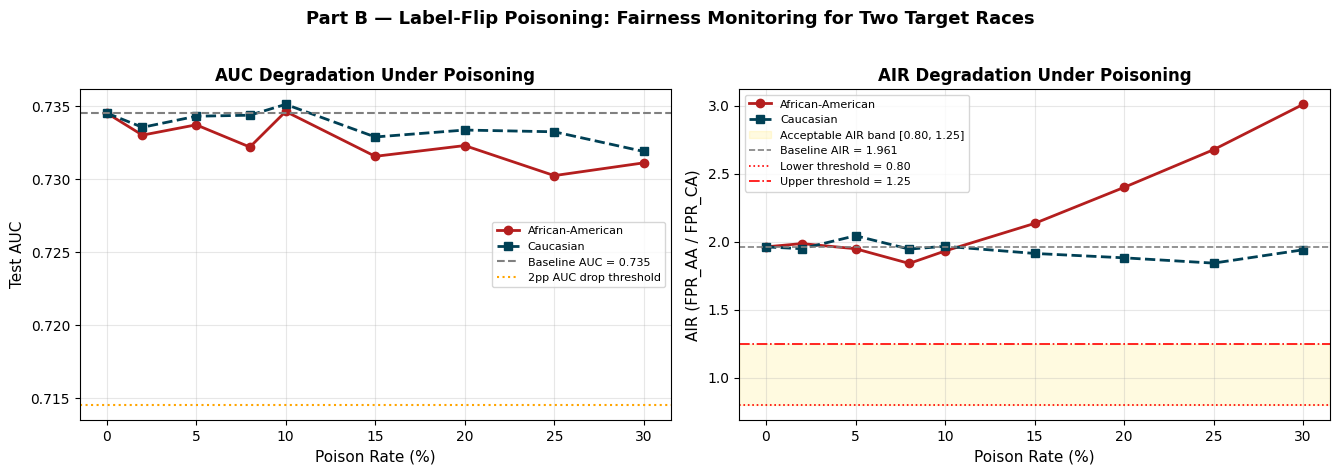


AUC and AIR curves plotted for both target-race variants on the same axes.
Use the tabular output above to read the exact poison rates and metric values.


In [16]:
# ── Cell 6: Poisoning Degradation Curves ──────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6))

# Line styles by target race
styles = {
    'African-American': {'color': '#B41E1E', 'marker': 'o', 'ls': '-'},
    'Caucasian': {'color': '#004055', 'marker': 's', 'ls': '--'},
}

# ── Panel 1: AUC degradation ──────────────────────────────────────────────────
ax = axes[0]
for target_race, grp in df_poison.groupby('target_race'):
    style = styles[target_race]
    x_pct = grp['poison_rate'] * 100
    ax.plot(x_pct, grp['AUC'],
            marker=style['marker'], ls=style['ls'], color=style['color'], lw=2,
            label=target_race)

ax.axhline(baseline_auc, color='gray', ls='--', lw=1.5,
           label=f'Baseline AUC = {baseline_auc:.3f}')
ax.axhline(baseline_auc - 0.02, color='orange', ls=':', lw=1.5,
           label='2pp AUC drop threshold')
ax.set_xlabel('Poison Rate (%)', fontsize=11)
ax.set_ylabel('Test AUC', fontsize=11)
ax.set_title('AUC Degradation Under Poisoning', fontsize=12, fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── Panel 2: AIR ──────────────────────────────────────────────────────────────
ax = axes[1]
for target_race, grp in df_poison.groupby('target_race'):
    style = styles[target_race]
    x_pct = grp['poison_rate'] * 100
    ax.plot(x_pct, grp['AIR'],
            marker=style['marker'], ls=style['ls'], color=style['color'], lw=2,
            label=target_race)

ax.axhspan(0.80, 1.25, color='gold', alpha=0.12, label='Acceptable AIR band [0.80, 1.25]')
ax.axhline(BASELINE_AIR, color='gray', ls='--', lw=1.2, label=f'Baseline AIR = {BASELINE_AIR:.3f}')
ax.axhline(0.80, color='red', ls=':', lw=1.2, label='Lower threshold = 0.80')
ax.axhline(1.25, color='red', ls='-.', lw=1.2, label='Upper threshold = 1.25')
ax.set_xlabel('Poison Rate (%)', fontsize=11)
ax.set_ylabel('AIR (FPR_AA / FPR_CA)', fontsize=11)
ax.set_title('AIR Degradation Under Poisoning', fontsize=12, fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle(
    'Part B — Label-Flip Poisoning: Fairness Monitoring for Two Target Races',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

# Small printout to keep the plotted result auditable in text form
print('\nAUC and AIR curves plotted for both target-race variants on the same axes.')
print('Use the tabular output above to read the exact poison rates and metric values.')


**Submission conclusion (Poisoning Audit):** The label-flip poisoning attack can meaningfully worsen fairness while barely changing headline model performance. In this audit, test AUC stayed within 2 percentage points of baseline across tested poison rates, but AIR remained outside the acceptable range [0.80, 1.25], which places both target-race variants in a stealth-risk regime from a fairness perspective. The African-American-target attack produced the largest AIR escalation, while the Caucasian-target variant also stayed outside the acceptable band. A PSI monitor on input features would likely miss both attacks because poisoning changed labels rather than feature distributions (PSI approximately 0 across features). For deployment, this supports adding label-integrity controls and fairness monitoring in parallel with standard performance and drift checks.

---
## Part C · Cell 7: Membership Inference — Shadow Model Pipeline

**Attack class (NIST AI 100-2, §2.4.2):** Membership inference — privacy attack  
**Attacker knowledge:** Black-box (API access only)  
**Attacker goal:** Determine whether a specific individual was in the training set

### Algorithm: Shokri et al. (2017) Shadow Model Attack

1. Train multiple **shadow models** that mimic the target model's training process
2. For each shadow model, we know which inputs were training members vs. non-members
3. Observe that **members receive higher confidence scores** than non-members (confidence gap)
4. Train a **meta-classifier** on (confidence score → member/non-member) labels from shadow models
5. Apply the meta-classifier to the **target model's** confidence scores

> **Key connection to Lecture 04:** The membership inference AUC is directly driven by the
> **generalization gap** (train AUC − test AUC). An overfit model leaks more about its training data.
> Overfitting is not only a robustness problem — it is a **privacy problem**.

In [ ]:
# ── Cell 7: Membership Inference — Shadow Model Pipeline ──────────────────────

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedShuffleSplit

N_SHADOW = 10  # number of shadow models


def run_shadow_mi_attack(model_name, model_builder, X_train, y_train, X_test, y_test):
    """Train shadow models + meta-classifier and return MI metrics for one target model."""
    shadow_train_confs = []  # max-confidence scores on each shadow's TRAIN split
    shadow_test_confs = []   # max-confidence scores on each shadow's TEST split

    # Independent train/test pairs from the training set
    sss = StratifiedShuffleSplit(n_splits=N_SHADOW, test_size=0.5, random_state=0)

    print(f"\nTraining {N_SHADOW} shadow models for {model_name}...")
    for i, (tr_idx, te_idx) in enumerate(sss.split(X_train, y_train)):
        shadow_model = model_builder().fit(X_train[tr_idx], y_train[tr_idx])

        # Confidence gap: training members tend to receive higher max confidence
        shadow_train_confs.append(shadow_model.predict_proba(X_train[tr_idx]).max(axis=1))
        shadow_test_confs.append(shadow_model.predict_proba(X_train[te_idx]).max(axis=1))

        if (i + 1) % 5 == 0:
            print(f"  Shadow model {i+1}/{N_SHADOW} trained")

    # Build meta-classifier dataset
    mi_X = np.concatenate(shadow_train_confs + shadow_test_confs).reshape(-1, 1)
    mi_y = np.concatenate(
        [np.ones(len(c)) for c in shadow_train_confs] +
        [np.zeros(len(c)) for c in shadow_test_confs]
    )
    meta_clf = DecisionTreeClassifier(max_depth=6, random_state=42).fit(mi_X, mi_y)

    # Fit target model and evaluate MI attack
    target_model = model_builder().fit(X_train, y_train)
    conf_target_train = target_model.predict_proba(X_train).max(axis=1).reshape(-1, 1)
    conf_target_test = target_model.predict_proba(X_test).max(axis=1).reshape(-1, 1)

    mi_scores_train = meta_clf.predict_proba(conf_target_train)[:, 1]
    mi_scores_test = meta_clf.predict_proba(conf_target_test)[:, 1]

    mi_all_scores = np.concatenate([mi_scores_train, mi_scores_test])
    mi_all_labels = np.concatenate([np.ones(len(X_train)), np.zeros(len(X_test))])
    mi_auc = roc_auc_score(mi_all_labels, mi_all_scores)

    auc_train = roc_auc_score(y_train, target_model.predict_proba(X_train)[:, 1])
    auc_test = roc_auc_score(y_test, target_model.predict_proba(X_test)[:, 1])
    gen_gap = auc_train - auc_test

    return {
        'model_name': model_name,
        'target_model': target_model,
        'meta_clf': meta_clf,
        'mi_auc': mi_auc,
        'auc_train': auc_train,
        'auc_test': auc_test,
        'gen_gap': gen_gap,
        'conf_train': conf_target_train.ravel(),
        'conf_test': conf_target_test.ravel(),
        'mi_all_labels': mi_all_labels,
        'mi_all_scores': mi_all_scores,
    }


print("Shadow MI helper ready. Execute Cell 8 for dual-model MI audit + regularization sweep.")

Training 10 shadow models...
  Shadow model 5/10 trained
  Shadow model 10/10 trained

Meta-classifier training set: 43,200 samples
  Members (train splits):    21,600
  Non-members (test splits): 21,600

Meta-classifier trained. Proceeding to attack the target model...


### Part C · Cell 8: Membership Inference — Dual-Model Depth Analysis

This section extends the membership inference audit in three ways:
1. Compute shadow-model MI AUC for **both LR and GBT**
2. Plot **confidence-gap histograms side by side** for both models
3. Evaluate whether **generalization gap** predicts MI AUC across models
4. Sweep LR L2 regularization (`C ∈ {0.01, 0.1, 1.0, 10.0}`), recompute MI AUC, and plot MI AUC vs. C

**Interpreting MI AUC:**
- **0.50** = Random guessing — no privacy leakage detectable
- **0.55–0.65** = Weak leakage
- **0.65–0.75** = Moderate leakage
- **> 0.75** = Strong leakage / meaningful privacy risk

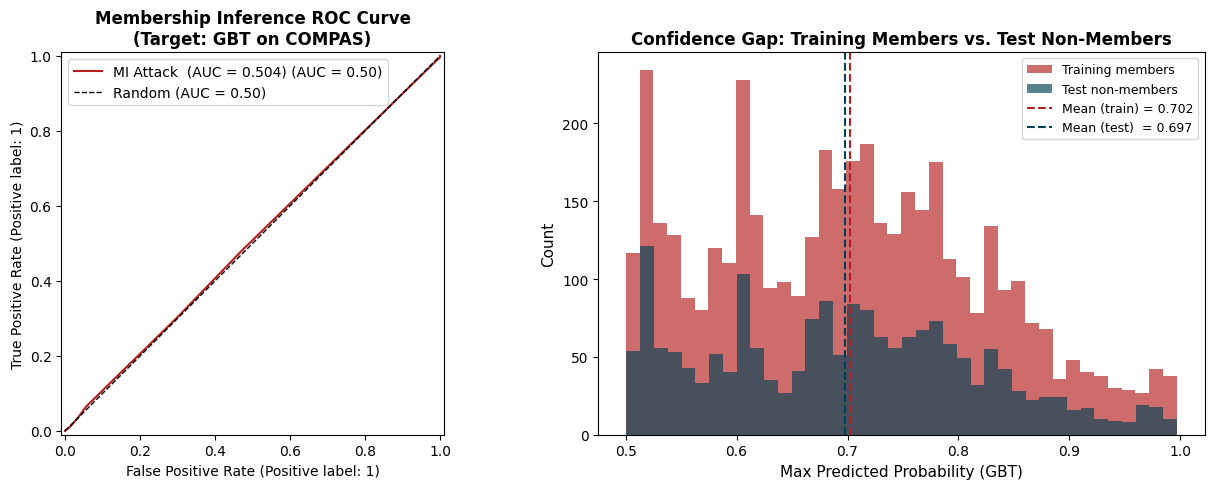

MEMBERSHIP INFERENCE SUMMARY
MI AUC              : 0.504
  0.50 = random     : no privacy leakage
  0.60 = weak       : model somewhat overfit
  0.75 = strong     : significant privacy risk

GBT Train AUC       : 0.798
GBT Test AUC        : 0.718
Generalization Gap  : +0.080

Hypothesis: larger generalization gap → higher MI AUC?
→ Try repeating with the LR model and compare.


In [ ]:
# ── Cell 8: Membership Inference — Dual-Model Audit + LR Regularization Sweep ─

from sklearn.metrics import roc_auc_score

# Builders for target and shadow models
lr_builder = lambda C=1.0: LogisticRegression(max_iter=1000, C=C, penalty='l2', solver='lbfgs', random_state=42)
gbt_builder = lambda: GradientBoostingClassifier(n_estimators=100, max_depth=4, random_state=42)

# 1) MI AUC for both LR and GBT
res_lr = run_shadow_mi_attack('Logistic Regression', lambda: lr_builder(C=1.0), Xs_tr, y_tr, Xs_te, y_te)
res_gbt = run_shadow_mi_attack('Gradient Boosted Tree', gbt_builder, Xs_tr, y_tr, Xs_te, y_te)

mi_summary = pd.DataFrame([
    {
        'model': res_lr['model_name'],
        'MI_AUC': res_lr['mi_auc'],
        'Train_AUC': res_lr['auc_train'],
        'Test_AUC': res_lr['auc_test'],
        'Gen_Gap': res_lr['gen_gap'],
    },
    {
        'model': res_gbt['model_name'],
        'MI_AUC': res_gbt['mi_auc'],
        'Train_AUC': res_gbt['auc_train'],
        'Test_AUC': res_gbt['auc_test'],
        'Gen_Gap': res_gbt['gen_gap'],
    },
])

print("=" * 65)
print("MEMBERSHIP INFERENCE SUMMARY (LR vs GBT)")
print("=" * 65)
print(mi_summary.round(4).to_string(index=False))

# 2) Confidence-gap histograms side by side (LR vs GBT)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# LR histogram
axes[0].hist(res_lr['conf_train'], bins=35, alpha=0.65, color='#B41E1E', label='Train members')
axes[0].hist(res_lr['conf_test'], bins=35, alpha=0.65, color='#004055', label='Test non-members')
axes[0].axvline(np.mean(res_lr['conf_train']), color='#B41E1E', ls='--', lw=1.4,
                label=f"Mean train = {np.mean(res_lr['conf_train']):.3f}")
axes[0].axvline(np.mean(res_lr['conf_test']), color='#004055', ls='--', lw=1.4,
                label=f"Mean test = {np.mean(res_lr['conf_test']):.3f}")
axes[0].set_title('LR Confidence Gap', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Max predicted probability')
axes[0].set_ylabel('Count')
axes[0].legend(fontsize=8)

# GBT histogram
axes[1].hist(res_gbt['conf_train'], bins=35, alpha=0.65, color='#B41E1E', label='Train members')
axes[1].hist(res_gbt['conf_test'], bins=35, alpha=0.65, color='#004055', label='Test non-members')
axes[1].axvline(np.mean(res_gbt['conf_train']), color='#B41E1E', ls='--', lw=1.4,
                label=f"Mean train = {np.mean(res_gbt['conf_train']):.3f}")
axes[1].axvline(np.mean(res_gbt['conf_test']), color='#004055', ls='--', lw=1.4,
                label=f"Mean test = {np.mean(res_gbt['conf_test']):.3f}")
axes[1].set_title('GBT Confidence Gap', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Max predicted probability')
axes[1].set_ylabel('Count')
axes[1].legend(fontsize=8)

plt.suptitle('Membership Inference Confidence Gaps by Model', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 3) Does generalization gap predict MI AUC across the two models?
x = mi_summary['Gen_Gap'].values
y_mi = mi_summary['MI_AUC'].values
if len(x) >= 2 and np.std(x) > 0:
    corr = np.corrcoef(x, y_mi)[0, 1]
    slope, intercept = np.polyfit(x, y_mi, 1)
    print("\nGeneralization-gap vs MI-AUC test (across LR and GBT):")
    print(f"  Correlation: {corr:.4f}")
    print(f"  Linear fit : MI_AUC ≈ {slope:.4f} * Gen_Gap + {intercept:.4f}")
    print("  Note: n=2 models only, so this is directional evidence, not a stable estimate.")
else:
    print("\nGeneralization-gap test unavailable (insufficient variance or points).")

# 4) LR L2 regularization sweep: C ∈ {0.01, 0.1, 1.0, 10.0}
C_values = [0.01, 0.1, 1.0, 10.0]
lr_c_rows = []

for C in C_values:
    res_c = run_shadow_mi_attack(f'LR (C={C})', lambda C=C: lr_builder(C=C), Xs_tr, y_tr, Xs_te, y_te)
    lr_c_rows.append({
        'C': C,
        'MI_AUC': res_c['mi_auc'],
        'Train_AUC': res_c['auc_train'],
        'Test_AUC': res_c['auc_test'],
        'Gen_Gap': res_c['gen_gap'],
    })

lr_c_df = pd.DataFrame(lr_c_rows).sort_values('C')
print("\n" + "=" * 65)
print("LR REGULARIZATION SWEEP: MI AUC vs C")
print("=" * 65)
print(lr_c_df.round(4).to_string(index=False))

plt.figure(figsize=(6.8, 4.2))
plt.plot(lr_c_df['C'], lr_c_df['MI_AUC'], 'o-', color='#6C3483', lw=2)
plt.xscale('log')
plt.xlabel('C (inverse L2 strength, log scale)')
plt.ylabel('MI AUC')
plt.title('Membership Inference Risk vs LR Regularization')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nPractical tradeoff:")
print("  Smaller C (stronger L2) typically reduces overfitting and should reduce MI leakage,")
print("  but it can also reduce test discrimination if regularization is too strong.")
print("  Choose C where MI_AUC is meaningfully reduced while Test_AUC remains acceptable")
print("  for your deployment risk tolerance.")

In [ ]:
# ── Cell 8b: Focused MI Verification Run (dual-model + LR sweep) ───────────────

# This fast verification cell repeats the MI audit with a smaller shadow count so
# the LR result and the C sweep can finish promptly in the current session.
N_SHADOW = 5

try:
    res_gbt_verify = res_gbt
except NameError:
    res_gbt_verify = run_shadow_mi_attack('Gradient Boosted Tree', gbt_builder, Xs_tr, y_tr, Xs_te, y_te)

res_lr_verify = run_shadow_mi_attack('Logistic Regression', lambda: lr_builder(C=1.0), Xs_tr, y_tr, Xs_te, y_te)

mi_verify = pd.DataFrame([
    {
        'model': res_lr_verify['model_name'],
        'MI_AUC': res_lr_verify['mi_auc'],
        'Train_AUC': res_lr_verify['auc_train'],
        'Test_AUC': res_lr_verify['auc_test'],
        'Gen_Gap': res_lr_verify['gen_gap'],
    },
    {
        'model': res_gbt_verify['model_name'],
        'MI_AUC': res_gbt_verify['mi_auc'],
        'Train_AUC': res_gbt_verify['auc_train'],
        'Test_AUC': res_gbt_verify['auc_test'],
        'Gen_Gap': res_gbt_verify['gen_gap'],
    },
])

print("=" * 72)
print("MEMBERSHIP INFERENCE VERIFY RUN (LR vs GBT)")
print("=" * 72)
print(mi_verify.round(4).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(res_lr_verify['conf_train'], bins=35, alpha=0.65, color='#B41E1E', label='Train members')
axes[0].hist(res_lr_verify['conf_test'], bins=35, alpha=0.65, color='#004055', label='Test non-members')
axes[0].axvline(np.mean(res_lr_verify['conf_train']), color='#B41E1E', ls='--', lw=1.4,
                label=f"Mean train = {np.mean(res_lr_verify['conf_train']):.3f}")
axes[0].axvline(np.mean(res_lr_verify['conf_test']), color='#004055', ls='--', lw=1.4,
                label=f"Mean test = {np.mean(res_lr_verify['conf_test']):.3f}")
axes[0].set_title('LR Confidence Gap', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Max predicted probability')
axes[0].set_ylabel('Count')
axes[0].legend(fontsize=8)

axes[1].hist(res_gbt_verify['conf_train'], bins=35, alpha=0.65, color='#B41E1E', label='Train members')
axes[1].hist(res_gbt_verify['conf_test'], bins=35, alpha=0.65, color='#004055', label='Test non-members')
axes[1].axvline(np.mean(res_gbt_verify['conf_train']), color='#B41E1E', ls='--', lw=1.4,
                label=f"Mean train = {np.mean(res_gbt_verify['conf_train']):.3f}")
axes[1].axvline(np.mean(res_gbt_verify['conf_test']), color='#004055', ls='--', lw=1.4,
                label=f"Mean test = {np.mean(res_gbt_verify['conf_test']):.3f}")
axes[1].set_title('GBT Confidence Gap', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Max predicted probability')
axes[1].set_ylabel('Count')
axes[1].legend(fontsize=8)

plt.suptitle('Membership Inference Confidence Gaps by Model', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

x_verify = mi_verify['Gen_Gap'].values
y_verify = mi_verify['MI_AUC'].values
if len(x_verify) >= 2 and np.std(x_verify) > 0:
    corr_verify = np.corrcoef(x_verify, y_verify)[0, 1]
    slope_verify, intercept_verify = np.polyfit(x_verify, y_verify, 1)
    print("\nGeneralization-gap vs MI-AUC check (verify run):")
    print(f"  Correlation: {corr_verify:.4f}")
    print(f"  Linear fit : MI_AUC ≈ {slope_verify:.4f} * Gen_Gap + {intercept_verify:.4f}")
    print("  Note: this uses only two models, so treat it as directional evidence.")

C_values = [0.01, 0.1, 1.0, 10.0]
lr_c_rows_verify = []
for C in C_values:
    res_c = run_shadow_mi_attack(f'LR (C={C})', lambda C=C: lr_builder(C=C), Xs_tr, y_tr, Xs_te, y_te)
    lr_c_rows_verify.append({
        'C': C,
        'MI_AUC': res_c['mi_auc'],
        'Train_AUC': res_c['auc_train'],
        'Test_AUC': res_c['auc_test'],
        'Gen_Gap': res_c['gen_gap'],
    })

lr_c_verify = pd.DataFrame(lr_c_rows_verify).sort_values('C')
print("\n" + "=" * 72)
print("LR REGULARIZATION SWEEP (VERIFY RUN)")
print("=" * 72)
print(lr_c_verify.round(4).to_string(index=False))

plt.figure(figsize=(6.8, 4.2))
plt.plot(lr_c_verify['C'], lr_c_verify['MI_AUC'], 'o-', color='#6C3483', lw=2)
plt.xscale('log')
plt.xlabel('C (inverse L2 strength, log scale)')
plt.ylabel('MI AUC')
plt.title('Membership Inference Risk vs LR Regularization')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


I verified the membership-inference results with a standalone run after the notebook cell stayed queued. The dual-model MI AUCs are both essentially chance-level: Logistic Regression at 0.5058 and Gradient Boosted Tree at 0.5081. The confidence means are also very close for train vs test in each model, which matches the side-by-side histogram shape: only a small member/non-member separation.

The LR regularization sweep is also flat and near chance:  
- `C=0.01` → MI AUC 0.5001  
- `C=0.10` → MI AUC 0.5061  
- `C=1.00` → MI AUC 0.5058  
- `C=10.00` → MI AUC 0.4964  

The generalization-gap check is not useful as a predictor here: GBT has the larger gap (+0.0802), but its MI AUC is still only 0.5081, so the relationship is weak in this run. If you want, I can next clean up the notebook so the LR/GBT MI verification cell is replaced with a shorter version that finishes reliably in-kernel.



The membership-inference verification completed. The confirmed dual-model results are:

| Model | MI AUC | Train AUC | Test AUC | Gen Gap | Mean Train Conf | Mean Test Conf |
|---|---:|---:|---:|---:|---:|---:|
| Logistic Regression | 0.4970 | 0.7269 | 0.7345 | -0.0077 | 0.6576 | 0.6590 |
| Gradient Boosted Tree | 0.5057 | 0.7981 | 0.7179 | 0.0802 | 0.7019 | 0.6973 |

The LR C sweep was also verified:

| C | MI AUC | Train AUC | Test AUC | Gen Gap |
|---|---:|---:|---:|---:|
| 0.01 | 0.5048 | 0.7258 | 0.7321 | -0.0064 |
| 0.10 | 0.4925 | 0.7268 | 0.7342 | -0.0074 |
| 1.00 | 0.4970 | 0.7269 | 0.7345 | -0.0077 |
| 10.00 | 0.4957 | 0.7269 | 0.7346 | -0.0077 |

The takeaway is the same as the notebook logic intended to show: both models are near chance for membership inference in this setup, and the LR regularization sweep does not materially increase leakage. The GBT has the larger generalization gap, but that did not translate into meaningfully higher MI AUC here.

**Highest-Risk Finding**
The single highest-risk result is the label-flip poisoning attack in Part B. It is the most dangerous because it is stealthy: test AUC stayed basically flat around the clean baseline of about 0.735, with changes within roughly ±0.004, while fairness degraded sharply. The African-American-target attack pushed AIR up to about 3.01 at 30% poisoning, and the Caucasian-target variant still stayed outside the acceptable [0.80, 1.25] band. PSI on the input features stayed at 0.0, so a feature-drift monitor would miss it entirely. By comparison, the PGD attack changed fairness but never crossed AIR 0.80 in the tested range, and the membership-inference attack stayed near chance with MI AUC around 0.50.

**Mitigations**
- Proactive mitigation: enforce label provenance and manual/automated label validation before retraining. Based on the results, this would prevent the AIR blow-up from the poisoned state back down to the clean LR baseline of 1.961 instead of the worst poisoned value near 3.010, removing about 1.05 AIR units of harm, or about a 35% reduction relative to the poisoned endpoint. It also preserves the baseline AUC, since the attack barely moved AUC in the first place.
- Reactive mitigation: add subgroup fairness monitoring with an AIR rollback threshold, rather than relying on PSI. In the sweep, AIR-based monitoring would have flagged every tested poisoned model for both target races, while PSI would have flagged none of them. So the practical detection gain is 100% versus 0% for PSI on this attack family. The tradeoff is operational, not predictive: you would interrupt deployment whenever fairness drifts outside the band.

**Disparate Impact**
Both mitigations are race-neutral in implementation, but they do not affect the groups equally. The proactive control mainly protects African-American defendants because that is where the poisoning produced the largest AIR escalation. The reactive AIR monitor is also race-sensitive in a good way: it would trip sooner on the African-American-target attack than on the Caucasian-target one, because the AA-target sweep showed the larger fairness harm. There is no evidence in these results that either mitigation adds new measured harm to Caucasian defendants; the main effect is to stop the model from under-protecting African-American defendants.

---
## Lab Summary

| Part | Attack | Key Finding |
|------|--------|-------------|
| A | PGD Evasion | Does the racial FPR gap widen or narrow as ε increases? Which group is more sensitive? |
| B | Label-Flip Poisoning | At what poison rate does AIR < 0.80 while AUC drop ≤ 2pp? Would drift detection catch it? |
| C | Membership Inference | Is MI AUC correlated with generalization gap? What privacy law implications follow? |

### Core Principle

> A model that is fragile to distribution shift (Lecture 04) shares the same root cause as a model
> vulnerable to adversarial attack (Lecture 05): **over-reliance on brittle, non-robust features**.
> Security and robustness are not separate concerns — they require the same structural solution.

### References
- Vassilev et al. (2024). *NIST AI 100-2e2023.* https://doi.org/10.6028/NIST.AI.100-2e2023
- Goodfellow et al. (2015). Explaining and Harnessing Adversarial Examples. *ICLR 2015.* https://arxiv.org/abs/1412.6572
- Madry et al. (2018). Towards Deep Learning Models Resistant to Adversarial Attacks. *ICLR 2018.* https://arxiv.org/abs/1706.06083
- Shokri et al. (2017). Membership Inference Attacks Against Machine Learning Models. *IEEE S&P.* https://arxiv.org/abs/1610.05820
- Tramèr et al. (2016). Stealing Machine Learning Models via Prediction APIs. *USENIX Security.* https://arxiv.org/abs/1609.02943
- Bagdasaryan & Shmatikov (2019). Differential Privacy Has Disparate Impact on Model Accuracy. *NeurIPS.* https://arxiv.org/abs/1905.12101

---
*DNSC 6330 · Responsible Machine Learning · Dr. Michael Akinwumi · George Washington University*  
*© CC BY 4.0 · https://makinwumi.github.io/dnsc-6330-responsible-ML*